###   Опросы


In [1]:
import pandas as pd
import numpy as np
import math

import matplotlib
import matplotlib.pyplot as plt
import random


%matplotlib inline
import os
os.chdir("C:/Users/olesh/data_analys/GI")
exp45=207800

In [2]:
def plot_top_characters( df, n=5, show_time=True, time_step=None, markers=None):
     # --- 1. Стирание индекса ---
    data = df.reset_index(drop=True)

    # --- 2. Определяем TOP-N по последнему голосу ---
    last_values = data.iloc[-1].drop("Время")
    top_chars = last_values.sort_values(ascending=False).head(n).index
    data_top = data[top_chars]

    # --- 3. X — порядковый номер голоса ---
    x = range(len(data_top))

     # --- 4. Размер графика ---
    plt.figure(figsize=(20, 10))

    # --- 5. Строим линии ---
    for char in top_chars:
        plt.plot(data_top.index, data_top[char], label=char, linewidth=2)

    # --- 6. Оформление ---
    plt.title(f"Рост голосов — TOP {n} персонажей", fontsize=18)
    plt.xlabel("Время", fontsize=14)
    plt.ylabel("Количество голосов", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)

    # --- 7. Управление подписями времени ---
    if show_time:
        if time_step is None:
            time_step = max(1, round(len(data) / 20))

        ticks = list(range(0, len(data), time_step))
        labels = data.loc[ticks, "Время"].dt.strftime("%d-%H:%M:%S") # "%m-%d-%H:%M:%S"
        plt.xticks(ticks, labels, rotation=45)
    else:
        plt.xticks([])

    # --- 8. Маркеры событий ---
    if markers:
        for time_str, label in markers:
            event_time = pd.to_datetime(time_str)

            idx = data[data["Время"] >= event_time].index.min()
            if pd.notna(idx):
                plt.axvline(idx, color="red", linestyle="--", alpha=0.7)
                plt.text(
                    idx,
                    plt.ylim()[1],
                    label + "   ",
                    rotation=90,
                    verticalalignment="top",
                    color="red",
                    fontsize=10
                )

    plt.tight_layout()
    plt.show()

In [3]:
def plot_top_place_characters( df, n=5, show_time=True, time_step=None, markers=None):
     # --- 1. Стирание индекса ---
    data = df.reset_index(drop=True)

    # --- 2. Определяем TOP-N по последнему голосу ---
    last_values = data.iloc[-1].drop("Время")
    top_chars = last_values.sort_values(ascending=False).head(n).index
    data_top = data[top_chars]
    # rank: 1 = лидер (больше голосов), N = наименее популярный
    ranks = data_top.rank(axis=1, method="min", ascending=False)

    # --- 3. X — порядковый номер голоса ---
    x = range(len(data_top))

    # --- Определяем позиции точек ---
    if time_step is None:
        time_step = max(1, round(len(data) / 20))
    points = list(range(0, len(data), time_step))

    if markers:
        for time_str, _ in markers:
            event_time = pd.to_datetime(time_str)
            idx = data["Время"].searchsorted(event_time)
            if idx < len(data):
                points.append(idx)
                
    if points[-1] != len(data) - 1:
        points.append(len(data) - 1)  # добавляем последний индекс
    points = sorted(points)

     # --- 4. Размер графика ---
    plt.figure(figsize=(20, 10))

   # --- 5. Рисуем линии «шагами» ---
    for char in top_chars:
        # создаём списки X и Y для step-линии
        x_vals = []
        y_vals = []
        for i in range(len(points)-1):
            start = points[i]
            end = points[i+1]
            # линия держится на предыдущем значении до следующей точки
            x_vals.extend([start, end])
            y_vals.extend([ranks[char].iloc[start], ranks[char].iloc[end]])
        plt.plot(x_vals, y_vals, label=char, linewidth=2)

    # --- 6. Оформление ---
    plt.title(f"TOP {n} персонажей", fontsize=18)
    plt.xlabel("Время", fontsize=14)
    plt.ylabel("Место", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)

    # --- 7. Управление подписями времени ---
    if show_time:
        if time_step is None:
            time_step = max(1, round(len(data) / 20))

        ticks = list(range(0, len(data), time_step))
        labels = data.loc[ticks, "Время"].dt.strftime("%d-%H:%M:%S") # "%m-%d-%H:%M:%S"
        plt.xticks(ticks, labels, rotation=45)
    else:
        plt.xticks([])

    # --- 8. Маркеры событий ---
    if markers:
        for time_str, label in markers:
            event_time = pd.to_datetime(time_str)

            idx = data[data["Время"] >= event_time].index.min()
            if pd.notna(idx):
                plt.axvline(idx, color="red", linestyle="--", alpha=0.7)
                plt.text(
                    idx,
                    plt.ylim()[1],
                    label + "   ",
                    rotation=90,
                    verticalalignment="top",
                    color="red",
                    fontsize=10
                )

    plt.tight_layout()
    plt.show()

### WuWa

In [4]:
characters = ["Альто", "Августа", "Байжи", "Брант", "Булин", "Калчаро", "Камелия", "Кантарелла", "Карлотта", "Картефия", "Чанли", "Чиса", "Чися",
              "Чаккона", "Данжин", "Энкор", "Галбрена", "Юно", "Цзянсинь", "Цзиньси", "Цзиянь", "Линъян", "Люми", "Лупа", "Линей", "Мортефи", "Фиби",
              "Фролова", "Цююань", "Рочча", "Ровер Женщина", "Ровер Мужчина", "Санхуа", "Таоци", "Хранительница Берегов", "Верина", "Сянли Яо",
              "Яньян", "Инь Линь", "Юху", "Янву", "Зани", "Чжечжи"]

In [5]:
excel_df = pd.read_excel('опрос.xlsx', sheet_name = 'WW2025', index_col=False)
excel_df = excel_df.rename(columns={"Отметка времени": "Время",
                         "Самые любимые персонажи по совокупности всех факторов, такие как дизайн, характер, действия в сюжете, играбельность.": "Ответ"})

In [6]:
excel_df["chars"] = excel_df["Ответ"].str.split(", ")
df_exp = excel_df.explode("chars")

In [8]:
votes_wide = (
    pd.crosstab(df_exp["Время"], df_exp["chars"])
      .reindex(columns=characters, fill_value=0)
      .sort_index()
)
votes_cumsum = votes_wide.cumsum()
result = votes_cumsum.reset_index()

In [9]:
result

chars,Время,Альто,Августа,Байжи,Брант,Булин,Калчаро,Камелия,Кантарелла,Карлотта,...,Таоци,Хранительница Берегов,Верина,Сянли Яо,Яньян,Инь Линь,Юху,Янву,Зани,Чжечжи
0,2026-01-05 19:59:22.999,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2026-01-05 19:59:26.647,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2026-01-05 19:59:38.334,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
3,2026-01-05 19:59:41.925,1,1,1,1,1,1,2,1,1,...,1,1,1,2,1,1,1,1,2,1
4,2026-01-05 19:59:42.693,1,1,1,1,1,1,2,1,1,...,1,1,1,2,1,1,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5040,2026-01-08 16:51:36.814,454,1686,295,1250,461,845,1761,1114,1856,...,124,2169,330,660,205,862,99,125,2150,290
5041,2026-01-08 16:52:34.524,454,1686,295,1250,461,845,1761,1114,1856,...,124,2169,330,660,205,862,99,125,2150,290
5042,2026-01-08 16:52:50.942,454,1686,295,1251,461,845,1761,1114,1856,...,124,2169,330,660,205,862,99,125,2151,290
5043,2026-01-08 16:53:00.835,454,1686,295,1251,461,845,1761,1114,1856,...,124,2169,330,660,205,862,99,125,2151,290


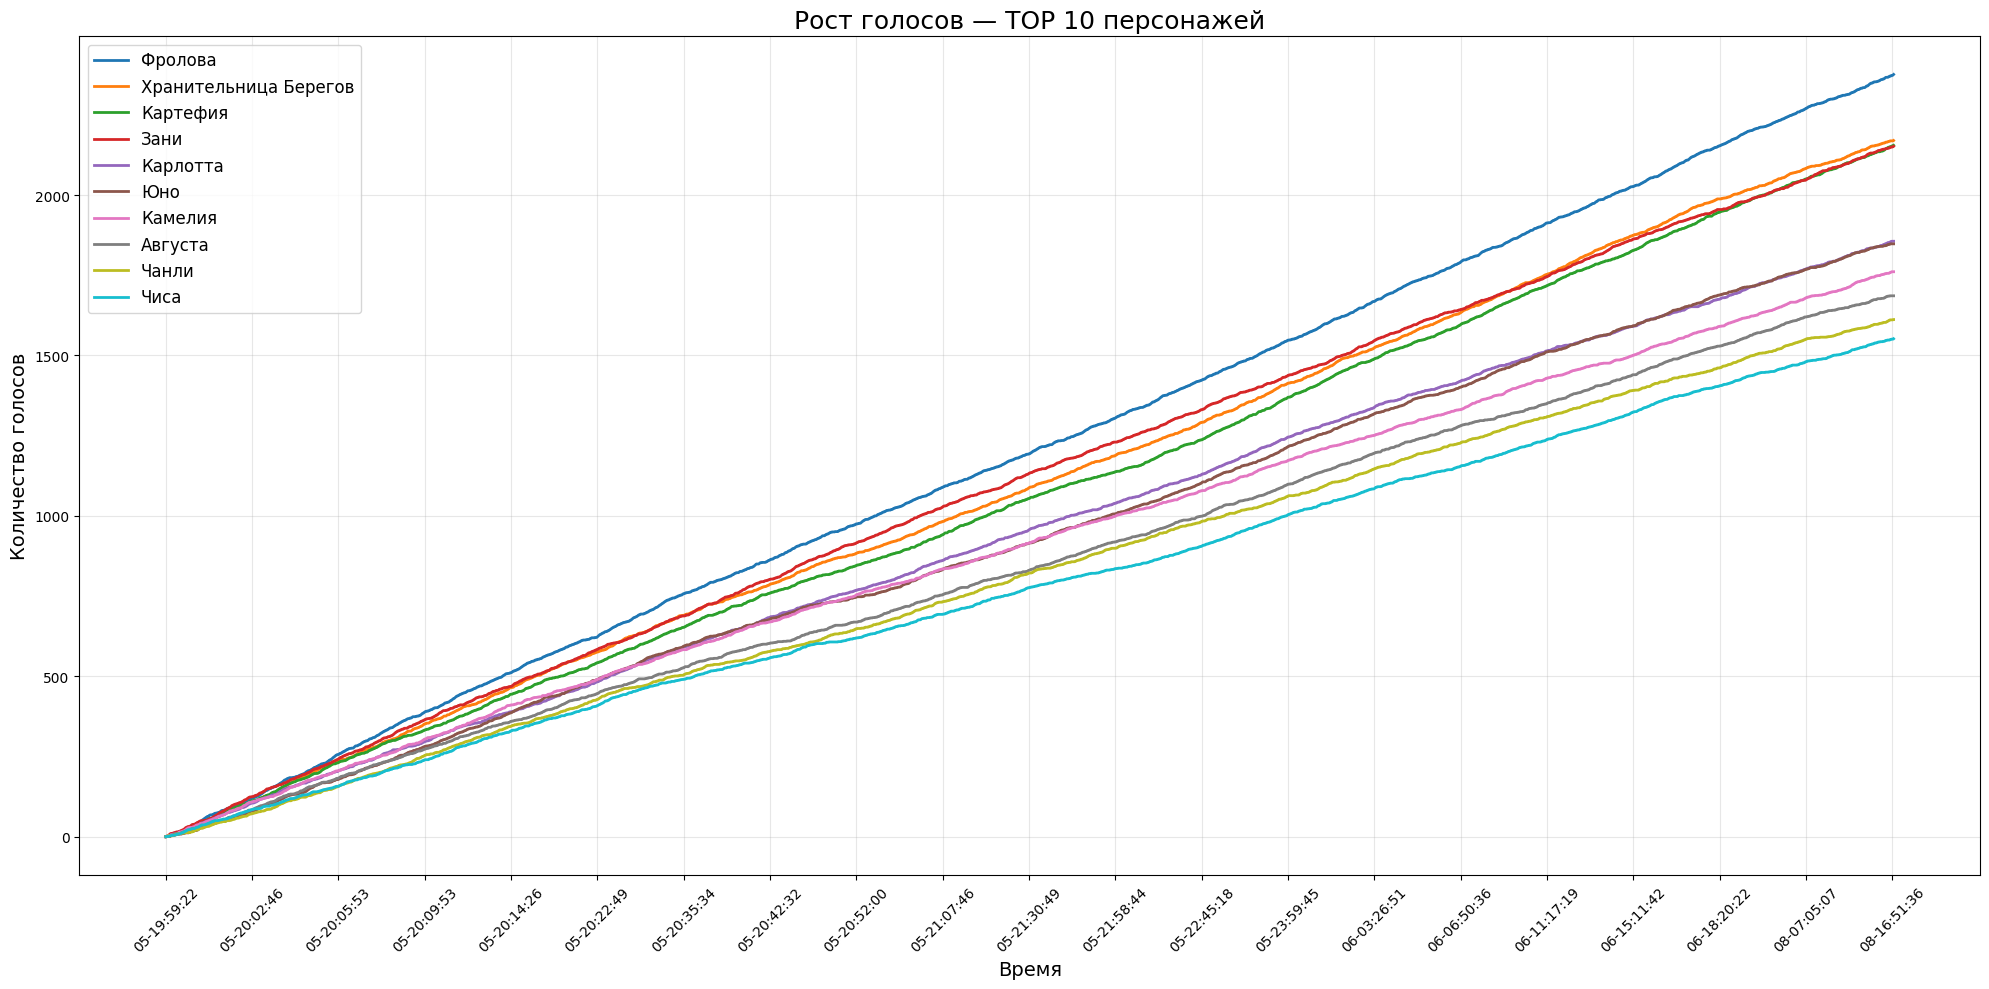

In [10]:
plot_top_characters(result, n=10)

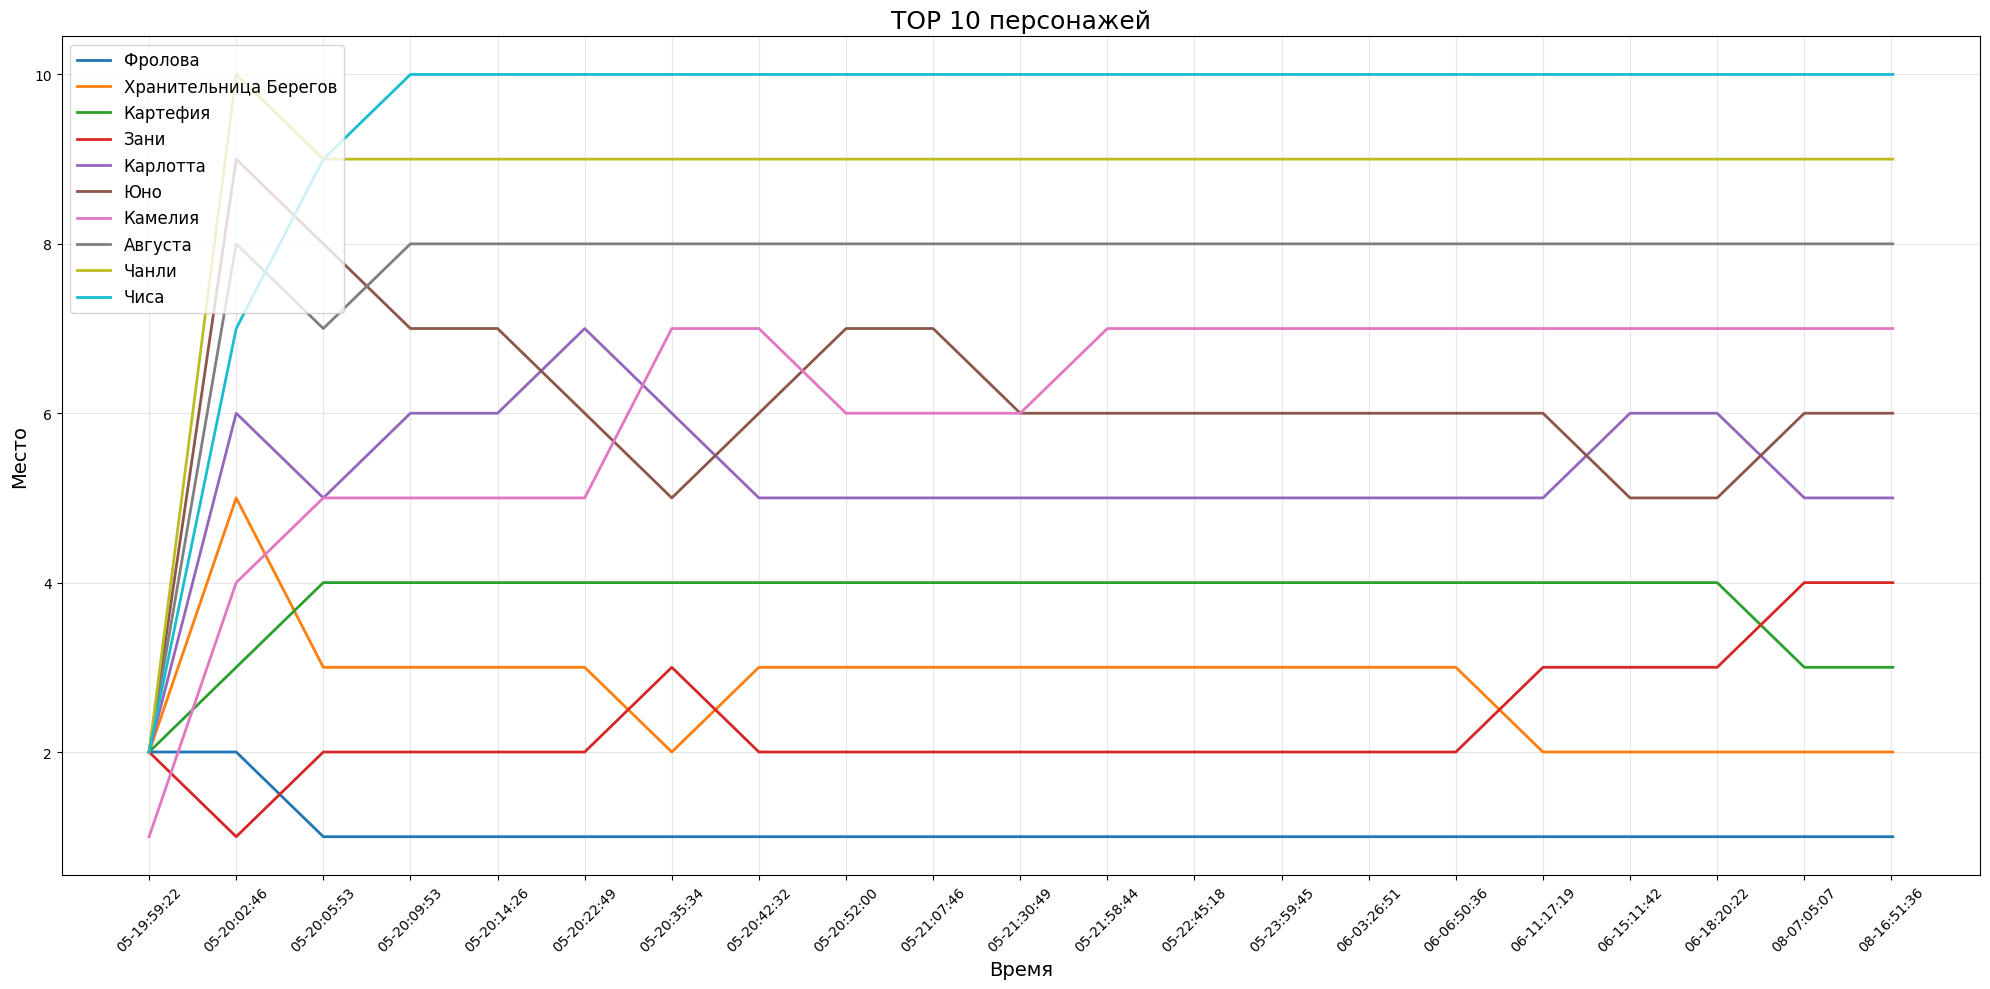

In [11]:
plot_top_place_characters(result, n=10)

### Genshin Impact

In [92]:
characters = ["Айно", "Аль-Хайтам", "Альбедо", "Арлекино", "Аяка", "Аято", "Бай Чжу", "Барбара", "Беннет", "Бэй Доу", "Вареса", "Венти", "Гань Юй",
              "Горо", "Далия", "Джинн", "Дилюк", "Диона", "Дори", "Дурин", "Дэхья", "Е Лань", "Ёимия", "Иансан", "Инеффа", "Итер", "Итто", "Ифа",
              "Ка Мин", "Кавех", "Кадзуха", "Кандакия", "Качина", "Кинич", "Кирара", "Кли", "Клоринда", "Кокоми", "Коллеи", "Коломбина",
              "Куки Синобу", "Кэ Цин", "Кэйа", "Лайла", "Лань Янь", "Лаума", "Лиза", "Линетт", "Лини", "Люмин", "Мавуика", "Мидзуки", "Мика", "Мона",
              "Муалани", "Навия", "Нахида", "Нёвиллет", "Нефер", "Нилу", "Нин Гуан", "Ноэлль", "Оророн", "Райдэн", "Ризли", "Розария", "Рэйзор",
              "Сайно", "Сара", "Сахароза", "Саю", "Сетос", "Сиджвин", "Син Цю", "Синь Янь", "Ситлали", "Скирк", "Странник", "Сян Лин", "Сянь Юнь",
              "Сяо", "Тарталья", "Тигнари", "Тиори", "Тома", "Фарузан", "Фишль", "Флинс", "Фремине", "Фурина", "Ху Тао", "Хэйдзо", "Ци Ци", "Часка",
              "Чжун Ли", "Чунь Юнь", "Шарлотта", "Шеврёз", "Шилонен", "Шэнь Хэ", "Элой", "Эмбер", "Эмилия", "Эола", "Эскофье", "Юнь Цзинь", "Ягода",
              "Янь Фэй", "Яо Яо", "Яэ Мико"]

In [93]:
excel_df = pd.read_excel('опрос.xlsx', sheet_name = 'G2025', index_col=False)
excel_df = excel_df.rename(columns={"Отметка времени": "Время",
                         "Самые любимые персонажи по совокупности всех факторов, такие как дизайн, характер, действия в сюжете, играбельность.": "Ответ"})

In [94]:
excel_df["chars"] = excel_df["Ответ"].str.split(", ")
df_exp = excel_df.explode("chars")

In [95]:
votes_wide = (
    pd.crosstab(df_exp["Время"], df_exp["chars"])
      .reindex(columns=characters, fill_value=0)
      .sort_index()
)
votes_cumsum = votes_wide.cumsum()
result = votes_cumsum.reset_index()

In [96]:
result

chars,Время,Айно,Аль-Хайтам,Альбедо,Арлекино,Аяка,Аято,Бай Чжу,Барбара,Беннет,...,Элой,Эмбер,Эмилия,Эола,Эскофье,Юнь Цзинь,Ягода,Янь Фэй,Яо Яо,Яэ Мико
0,2025-12-26 08:59:45.152,0,0,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2025-12-26 14:24:35.593,0,0,1,1,2,1,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,2025-12-26 14:24:56.474,0,1,1,1,2,2,1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,2025-12-26 14:25:27.980,1,2,2,1,2,2,1,0,0,...,0,0,0,0,1,0,1,0,0,0
4,2025-12-26 14:25:32.323,1,2,3,2,2,2,1,0,0,...,0,0,0,0,1,0,2,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15498,2025-12-30 12:35:38.323,1547,4715,3989,8706,2447,2410,1881,808,2952,...,245,667,1339,1960,2849,566,3300,1416,774,5159
15499,2025-12-30 12:37:56.319,1547,4716,3989,8707,2447,2411,1881,808,2952,...,245,667,1339,1960,2850,566,3300,1416,774,5160
15500,2025-12-30 12:55:46.483,1547,4716,3989,8707,2447,2411,1881,808,2952,...,245,667,1339,1960,2850,566,3300,1416,774,5160
15501,2025-12-30 13:18:00.028,1547,4716,3989,8707,2447,2411,1881,808,2952,...,245,667,1339,1960,2850,566,3300,1416,774,5160


In [112]:
markers = [

    ("2025-12-26 14:31:00", "Muuurrchik"),
    ("2025-12-26 17:19:00", "AxeSay"),
    ("2025-12-26 23:46:00", "AnimeCool"),
    ("2025-12-27 9:26:00", "Miron Min Max"),
]

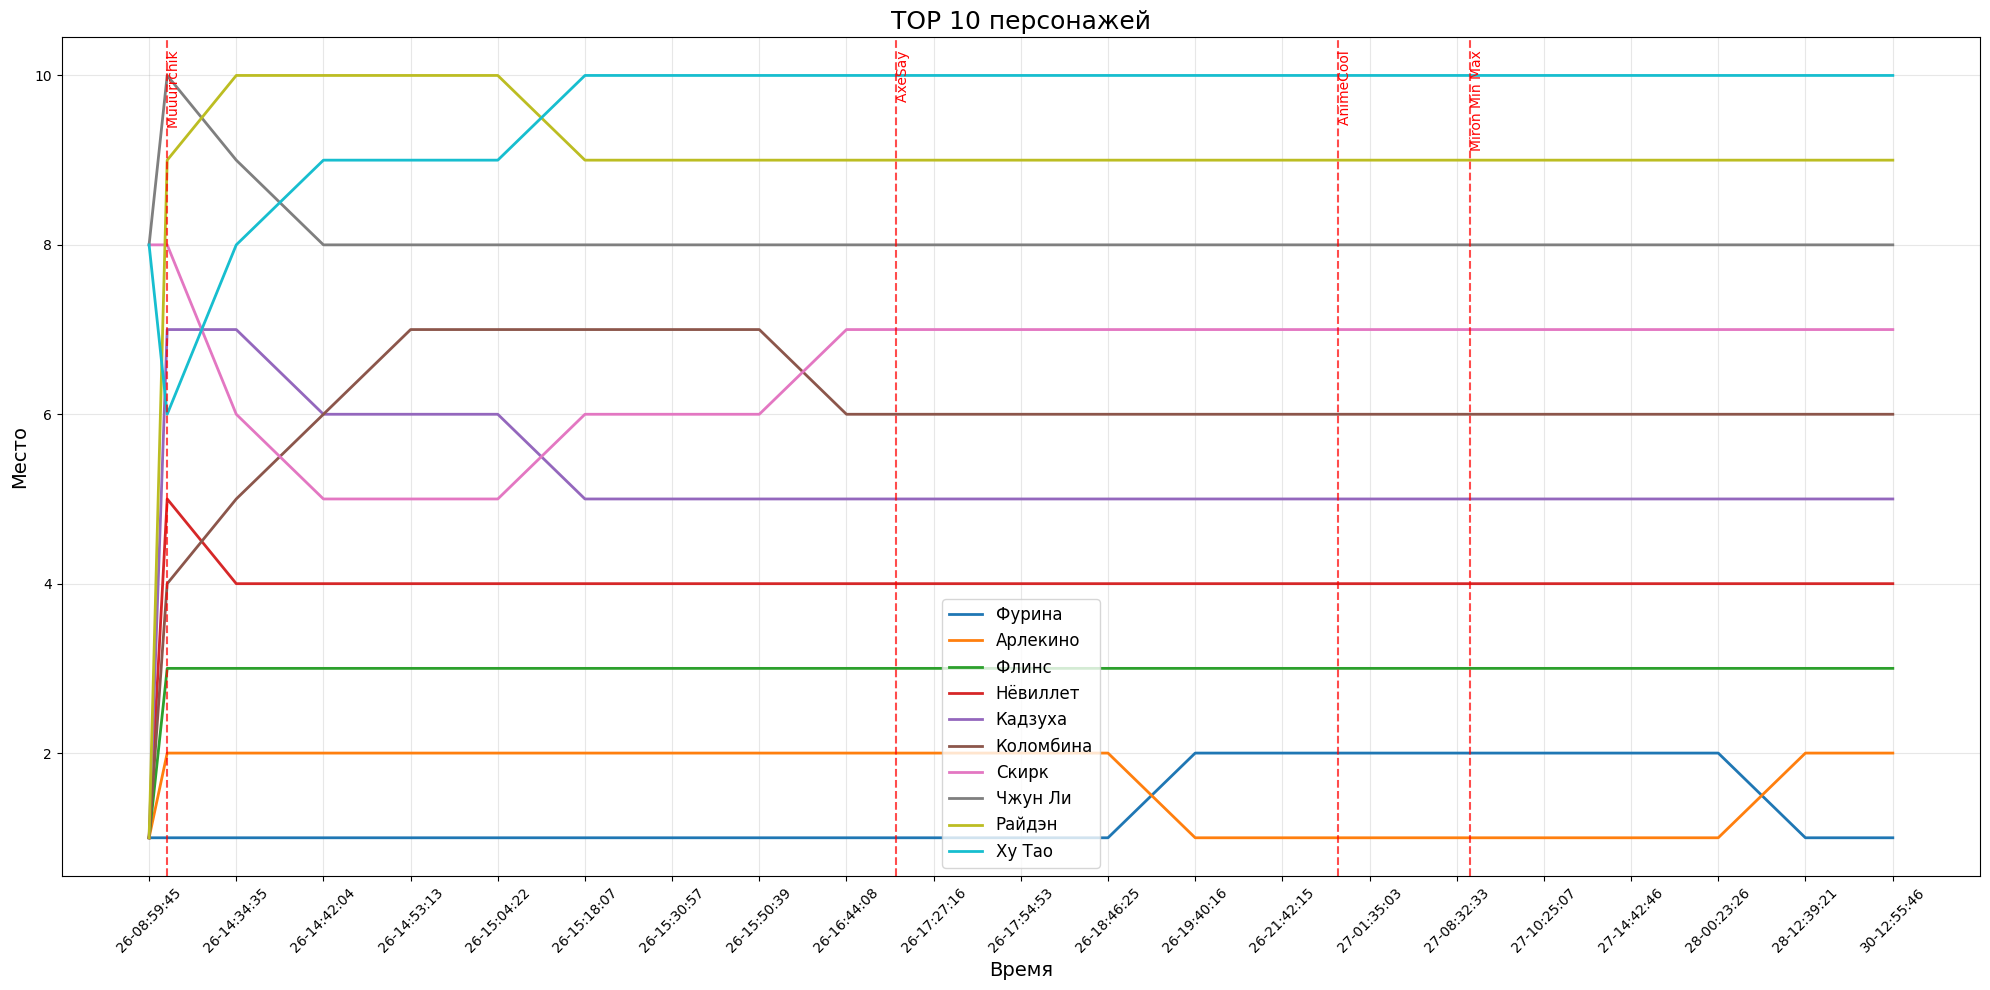

In [125]:
plot_top_place_characters(result, n=10, markers=markers)

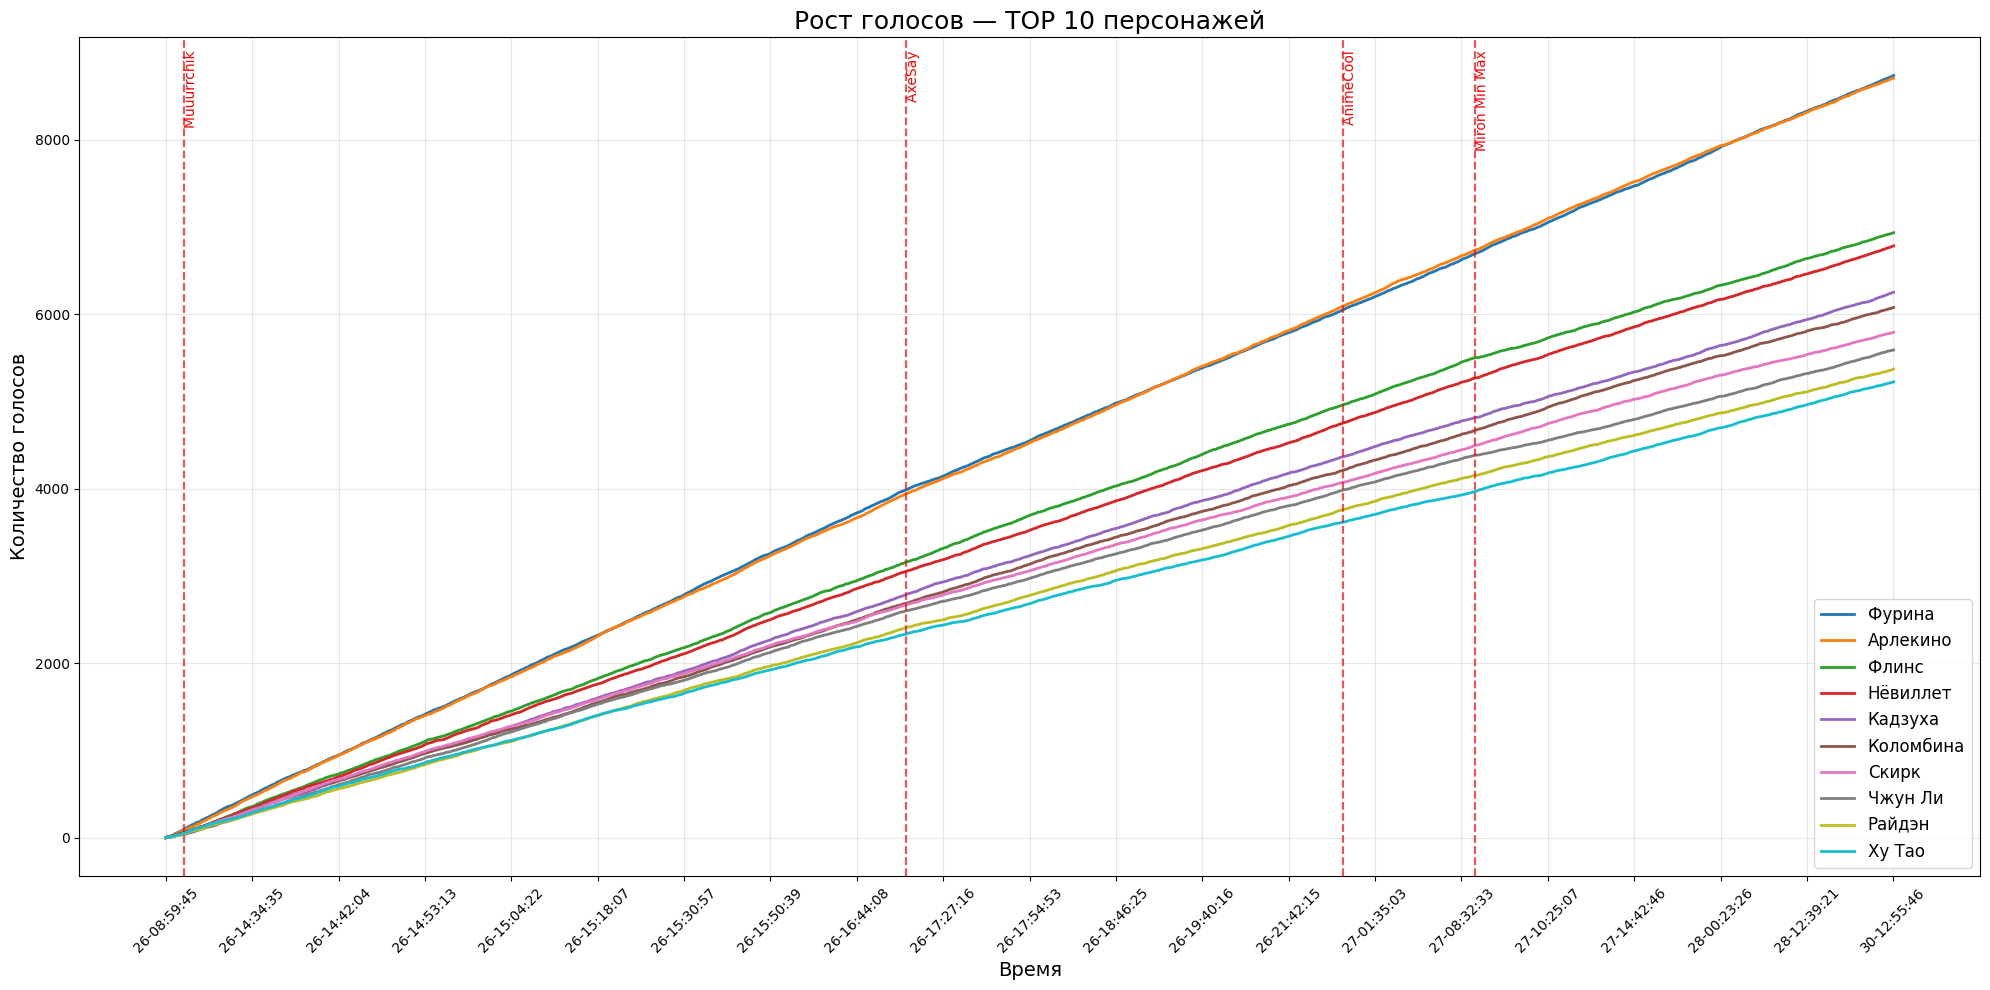

In [128]:
plot_top_characters(result, n=10, markers=markers)

In [79]:
for time_str, label in markers:
    event_time = pd.to_datetime(time_str)

    idx = result[result["Время"] >= event_time].index.min()
    print(idx)

0
0
0


In [80]:
result.dtypes

chars
Время                    datetime64[ns]
Альто                             int64
Августа                           int64
Байжи                             int64
Брант                             int64
Булин                             int64
Калчаро                           int64
Камелия                           int64
Кантарелла                        int64
Карлотта                          int64
Картефия                          int64
Чанли                             int64
Чиса                              int64
Чися                              int64
Чаккона                           int64
Данжин                            int64
Энкор                             int64
Галбрена                          int64
Юно                               int64
Цзянсинь                          int64
Цзиньси                           int64
Цзиянь                            int64
Линъян                            int64
Люми                              int64
Лупа                              

In [ ]:
def plot_top_characters_old( df, n=5, show_time=True, time_step=None):
    if time_step is None:
        time_step = round(len(result) / 20)
     # --- 1. Время в индекс ---
    data = df.set_index("Время")

    # --- 2. Определяем TOP-N по последнему голосу ---
    last_values = data.iloc[-1]
    top_chars = last_values.sort_values(ascending=False).head(n).index
    data_top = data[top_chars]

     # --- 3. Размер графика ---
    plt.figure(figsize=(20, 10))

    # --- 4. Строим линии ---
    for char in top_chars:
        plt.plot(data_top.index, data_top[char], label=char, linewidth=2)

    # --- 5. Оформление ---
    plt.title(f"Рост голосов — TOP {n} персонажей", fontsize=18)
    plt.xlabel("Время", fontsize=14)
    plt.ylabel("Количество голосов", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)

    # --- 6. Управление подписями времени ---
    if not show_time:
        plt.xticks([])
    else:
        ticks = data_top.index[::time_step]
        plt.xticks(ticks, rotation=45)

    plt.tight_layout()
    plt.show()

In [26]:
# --- 1. Удаляем пустые голоса ---
excel_data_df = excel_data_df.dropna()
# --- 2. Оставляем строки с 1 или 2 персонажами ---
# считаем запятые
excel_data_df["comma_count"] = excel_data_df["Ответ"].str.count(",")
# нам нужны строки с 0 или 1 запятой
excel_data_df = excel_data_df[excel_data_df["comma_count"] <= 1]
# лишняя колонка больше не нужна
excel_data_df = excel_data_df.drop(columns=["comma_count"])
# разделяем колонки по 1 персонажу
excel_data_df["chars"] = excel_data_df["Ответ"].str.split(", ")
excel_data_df = excel_data_df.explode("chars")
excel_data_df = excel_data_df.drop(columns=["Ответ"])
# убеждаемся, что timestamp — datetime
excel_data_df["Время"] = pd.to_datetime(excel_data_df["Время"])

<ipython-input-26-586534dbfecc>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  excel_data_df["comma_count"] = excel_data_df["Ответ"].str.count(",")


In [28]:
# --- 3. Смотрим групы одинаковых голосов ---
# сортируем, чтобы разница во времени считалась подряд
excel_data_df = excel_data_df.sort_values("Время")
# считаем разницу во времени в каждой группе одинаковых голосов
excel_data_df["time_diff"] = excel_data_df.groupby("chars")["Время"].diff()

In [29]:
# --- 4. Оставляем только строки, где разница < 1 минуты ---
result = excel_data_df[excel_data_df["time_diff"] < pd.Timedelta(minutes=1)]
result

In [ ]:
series = result.groupby("chars").size()
print(series)

In [39]:
series

chars
Антон               1
Астра Яо            3
Баньюэ             37
Билли               1
Бёрнис              3
Вивиан             12
Гашетка            11
Джейн              28
Диалинь            17
Исюань             22
Йидхари Мёрфи       6
Комано Монато      22
Лайтер             22
Ликаон             27
Люси                1
Мияби              66
Николь              1
Орфея и Магус      22
Пайпер              4
Пульхра             1
Сид               104
Сокаку              1
Солдат 0 Энби       2
Укинами Юдзуха     21
Харумаса            5
Хуго Влад          20
Цезарь              2
Цзюй Фуфу           4
Цинъи               1
Чжу Юань            2
Эвелин              9
Элис Таймфилд       8
Эллен              11
Энби                5
Янаги               2
dtype: int64